# DL_PR5 — Sentiment Analysis with RNN, LSTM and GRU
**Red & White Skill Education · Deep Learning · Module 9**

Dataset: IMDB Dataset of 50K Movie Reviews (Kaggle). Original source: Maas et al., 2011, Stanford AI Lab (Large Movie Review Dataset).

## Task 1: Text Loading, Cleaning, Tokenisation & Padding
**Objective:** Turn raw review text into clean, padded integer sequences without data leakage.

**Expected output:** Cleaned reviews, length plots, `x_train / x_test` padded arrays and their labels.

### Step 1.0 — Set random seeds

In [1]:
import numpy as np
import tensorflow as tf

np.random.seed(42)
tf.random.set_seed(42)

### Step 1.1 — Load and inspect the data

In [2]:
import pandas as pd

df = pd.read_csv('IMDB Dataset.csv')
print(df.shape)

(50000, 2)


In [3]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
print(df['sentiment'].value_counts())

sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [5]:
print(df.isnull().sum())

review       0
sentiment    0
dtype: int64


### Step 1.1 — Two raw reviews (look for HTML tags and punctuation)

In [6]:
for i in range(2):
    print('Review', i + 1, ':')
    print(df['review'][i])
    print('-' * 80)

Review 1 :
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due

**Interpretation**
- The data has two columns: `review` and `sentiment`.
- Classes are balanced (25,000 each) and there are no null values.
- Raw reviews contain HTML tags like `<br />` and mixed punctuation, so cleaning is needed.

### Step 1.2 — Remove duplicates

In [7]:
rows_before = len(df)
print('Duplicates:', df.duplicated().sum())

Duplicates: 418


In [8]:
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print('Rows before:', rows_before)
print('Rows after :', len(df))

Rows before: 50000
Rows after : 49582


**Why remove duplicates BEFORE the split?**
- If the same review is in both train and test, the model has already seen the test review.
- This is **data leakage** and it makes the test accuracy look better than it really is.

### Step 1.3 — Clean the text

In [9]:
import re

def clean_text(s):
    s = s.lower()
    s = re.sub(r'<.*?>', ' ', s)
    s = re.sub(r"[^a-z']", ' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s

In [10]:
sample = df['review'][1]
print('BEFORE:', sample[:400])
print()
print('AFTER :', clean_text(sample)[:400])

BEFORE: A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only "has got all the polari" but he has all the voices down pat too! You can truly see the seamless editing guided by the referen

AFTER : a wonderful little production the filming technique is very unassuming very old time bbc fashion and gives a comforting and sometimes discomforting sense of realism to the entire piece the actors are extremely well chosen michael sheen not only has got all the polari but he has all the voices down pat too you can truly see the seamless editing guided by the references to williams' diary entries no


In [11]:
df['clean'] = df['review'].apply(clean_text)

**Why this way?**
- Apostrophes are kept so `don't` and `can't` stay as meaningful words.
- Stop-words are **not** removed, because words like `not` and `no` flip the sentiment and word order matters for sequence models.

### Step 1.4 — Review length analysis

In [12]:
df['word_count'] = df['clean'].str.split().str.len()
df['word_count'].describe()

count    49582.000000
mean       229.961518
std        170.374347
min          6.000000
25%        126.000000
50%        172.000000
75%        279.000000
max       2462.000000
Name: word_count, dtype: float64

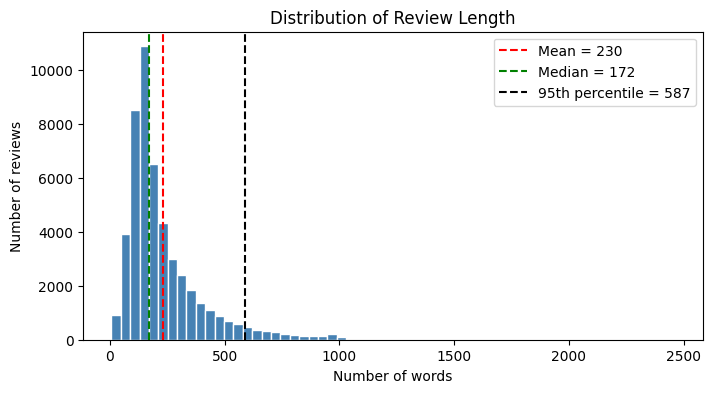

In [13]:
import os
import matplotlib.pyplot as plt

os.makedirs('plots', exist_ok=True)

mean_len = df['word_count'].mean()
median_len = df['word_count'].median()
p95_len = np.percentile(df['word_count'], 95)

plt.figure(figsize=(8, 4))
plt.hist(df['word_count'], bins=60, color='steelblue', edgecolor='white')
plt.axvline(mean_len, color='red', linestyle='--', label='Mean = ' + str(round(mean_len)))
plt.axvline(median_len, color='green', linestyle='--', label='Median = ' + str(round(median_len)))
plt.axvline(p95_len, color='black', linestyle='--', label='95th percentile = ' + str(round(p95_len)))
plt.title('Distribution of Review Length')
plt.xlabel('Number of words')
plt.ylabel('Number of reviews')
plt.legend()
plt.savefig('plots/length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

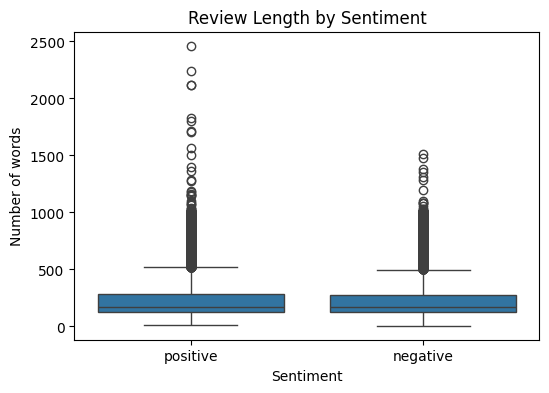

In [14]:
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.boxplot(x='sentiment', y='word_count', data=df)
plt.title('Review Length by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Number of words')
plt.show()

**Interpretation**
- The length is right-skewed: the mean is higher than the median because of a few very long reviews.
- Positive and negative reviews have a similar length, so length alone does not give the label.
- We will pad to about the 90th percentile (next step) so most reviews are kept in full and the very long ones are cut.

### Step 1.5 — Split first (before the tokenizer)

In [15]:
from sklearn.model_selection import train_test_split

x = df['clean']
y = (df['sentiment'] == 'positive').astype(int).values

x_train_text, x_test_text, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y)

print('Train:', len(x_train_text), ' Test:', len(x_test_text))
print('Positive share in train:', y_train.mean().round(3))
print('Positive share in test :', y_test.mean().round(3))

Train: 39665  Test: 9917
Positive share in train: 0.502
Positive share in test : 0.502


### Step 1.6 — Tokenise (fit on TRAIN only)

In [16]:
from tensorflow.keras.preprocessing.text import Tokenizer

vocab_size = 10000
tokenizer = Tokenizer(num_words=vocab_size, oov_token='<OOV>')
tokenizer.fit_on_texts(x_train_text)

In [17]:
top_words = list(tokenizer.word_index.items())[:10]
print(top_words)

[('<OOV>', 1), ('the', 2), ('and', 3), ('a', 4), ('of', 5), ('to', 6), ('is', 7), ('in', 8), ('it', 9), ('i', 10)]


In [18]:
train_seq = tokenizer.texts_to_sequences(x_train_text)
test_seq = tokenizer.texts_to_sequences(x_test_text)

print(x_train_text.iloc[0][:200])
print(train_seq[0][:30])

i am one of jehovah's witnesses and i also work in an acute care medical facility over the years i have seen people die from hemolytic reactions to blood transfusions have attended numerous conference
[10, 234, 27, 5, 1, 4935, 3, 10, 81, 158, 8, 32, 1, 454, 2767, 7929, 121, 2, 151, 10, 25, 105, 83, 705, 35, 1, 3781, 6, 547, 1]


**Why `num_words=10000` and the OOV token?**
- Rare words add many parameters and mostly noise, so only the 10,000 most frequent words are kept.
- Every other word is replaced by the `<OOV>` token, so unseen words in test data do not break the model.
- The tokenizer is fitted on training text only, so test data never influences the vocabulary.

### Step 1.7 — Pad / truncate

In [19]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

maxlen = int(round(np.percentile(df['word_count'], 90), -1))
print('Chosen MAXLEN:', maxlen)

Chosen MAXLEN: 450


In [20]:
x_train = pad_sequences(train_seq, maxlen=maxlen, padding='pre', truncating='pre')
x_test = pad_sequences(test_seq, maxlen=maxlen, padding='pre', truncating='pre')

print('x_train:', x_train.shape, ' y_train:', y_train.shape)
print('x_test :', x_test.shape, ' y_test :', y_test.shape)

x_train: (39665, 450)  y_train: (39665,)
x_test : (9917, 450)  y_test : (9917,)


**Why pre-padding?**
- An RNN that uses the last time step should end on real words, not on a long run of zeros.
- With `padding='pre'` the zeros come first and the real words are at the end, so the final hidden state is built from real text.

### Step 1.8 — Why this data is sequential
- `the movie was not good` and `the movie was good, not bad` have almost the same words but opposite meaning.
- A model that ignores order (bag-of-words) cannot separate them.
- So we need a model that reads words in order. This is the motivation for Task 2.

### Task 1 — Final interpretation
- Data was loaded, de-duplicated and cleaned (HTML removed, lowercase, stop-words kept).
- Split was done before tokenising, so there is no leakage.
- Reviews are now fixed-length integer sequences, ready for neural networks.

## Task 2: RNN Intuition, RNN vs ANN & Forward Propagation
**Objective:** Show why an order-blind ANN is weak for text and understand how an RNN cell computes its hidden state.

**Expected output:** ANN baseline results, a manual NumPy RNN forward pass verified against Keras, and the parameter formula check.

### Step 2.1 — Baseline ANN (order-blind)

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, Flatten, Dense

ann = Sequential([
    Input(shape=(maxlen,)),
    Embedding(vocab_size, 32),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])
ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
ann.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 450, 32)             │         320,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 14400)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │         921,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,241,729 (4.74 MB)

 Trainable params: 1,241,729 (4.74 MB)

 Non-trainable params: 0 (0.00 B)

### Helper tools (timer, train, plot, evaluate)
These small helpers are reused for every model so each comparison is fair.

In [22]:
import time
from tensorflow.keras.callbacks import Callback, EarlyStopping

class EpochTimer(Callback):
    def on_train_begin(self, logs=None):
        self.times = []
    def on_epoch_begin(self, epoch, logs=None):
        self.start = time.time()
    def on_epoch_end(self, epoch, logs=None):
        self.times.append(time.time() - self.start)

In [23]:
histories = {}
timers = {}

def train_model(name, model, epochs=15, early_stop=True):
    timer = EpochTimer()
    callbacks = [timer]
    if early_stop:
        callbacks.append(EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True))
    history = model.fit(x_train, y_train, epochs=epochs, batch_size=64,
                        validation_split=0.1, callbacks=callbacks, verbose=1)
    histories[name] = history.history
    timers[name] = timer.times
    return history

In [24]:
def plot_curves(name):
    h = histories[name]
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(h['loss'], label='Train')
    plt.plot(h['val_loss'], label='Validation')
    plt.title(name + ' — Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(h['accuracy'], label='Train')
    plt.plot(h['val_accuracy'], label='Validation')
    plt.title(name + ' — Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

In [25]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, classification_report, confusion_matrix)

results = {}
probs = {}
models = {}

def evaluate_model(name, model):
    prob = model.predict(x_test, verbose=0).ravel()
    pred = (prob > 0.5).astype(int)

    results[name] = {
        'Parameters': model.count_params(),
        'Time per Epoch (s)': round(np.mean(timers[name]), 2),
        'Epochs Trained': len(histories[name]['loss']),
        'Test Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1': f1_score(y_test, pred),
        'ROC-AUC': roc_auc_score(y_test, prob)
    }
    probs[name] = prob
    models[name] = model

    print(classification_report(y_test, pred, target_names=['negative', 'positive']))
    sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt='d', cmap='Blues',
                xticklabels=['negative', 'positive'], yticklabels=['negative', 'positive'])
    plt.title(name + ' — Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    print('Test accuracy:', round(results[name]['Test Accuracy'], 4))
    print('ROC-AUC      :', round(results[name]['ROC-AUC'], 4))

### Step 2.1 — Train and evaluate the ANN baseline (5 epochs)

In [26]:
ann_history = train_model('ANN baseline', ann, epochs=5, early_stop=False)

Epoch 1/5
558/558 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.8107 - loss: 0.3925 - val_accuracy: 0.8820 - val_loss: 0.2848
Epoch 2/5
558/558 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9463 - loss: 0.1461 - val_accuracy: 0.8669 - val_loss: 0.3470
Epoch 3/5
558/558 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9865 - loss: 0.0430 - val_accuracy: 0.8543 - val_loss: 0.5163
Epoch 4/5
558/558 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9978 - loss: 0.0090 - val_accuracy: 0.8583 - val_loss: 0.5750
Epoch 5/5
558/558 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 0.8654 - val_loss: 0.6051


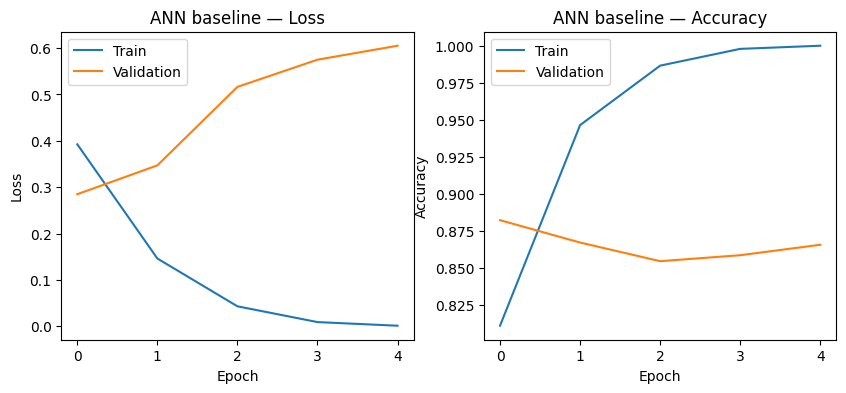

In [27]:
plot_curves('ANN baseline')

              precision    recall  f1-score   support

    negative       0.86      0.87      0.87      4940
    positive       0.87      0.85      0.86      4977

    accuracy                           0.86      9917
   macro avg       0.86      0.86      0.86      9917
weighted avg       0.86      0.86      0.86      9917



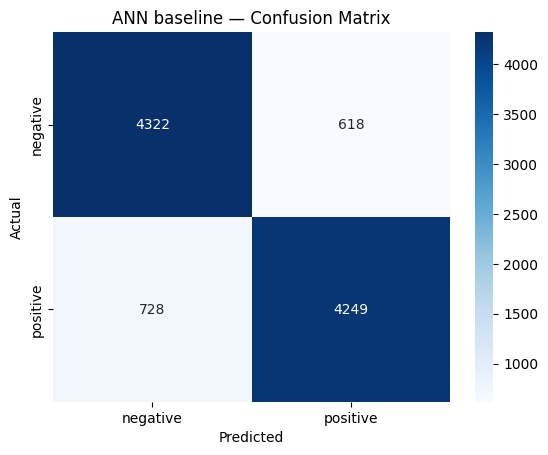

Test accuracy: 0.8643
ROC-AUC      : 0.9365


In [28]:
evaluate_model('ANN baseline', ann)

**Interpretation**
- The ANN reads the review as one long flat vector. Each position has its own weights, so it cannot reuse what it learned about a word at another position.
- Its parameters depend on `MAXLEN` (the Dense layer after Flatten grows with sequence length).
- Training accuracy usually rises fast but validation stops improving early, a sign of overfitting.

In [29]:
print('ANN total parameters:', ann.count_params())
print('Flatten output size  :', maxlen * 32, '(= MAXLEN x embedding size)')

ANN total parameters: 1241729
Flatten output size  : 14400 (= MAXLEN x embedding size)


### Step 2.2 — RNN intuition
- An RNN reads one word at a time and keeps a hidden state `h(t)` that summarises everything read so far.
- The **same weights** are reused at every time step (weight sharing across time), so any length works with a fixed number of parameters.
- Equation: `h(t) = tanh(Wxh · x(t) + Whh · h(t-1) + b)`
  - `x(t)` = current word vector
  - `h(t-1)` = memory from the previous step
  - `Wxh` = input weights, `Whh` = recurrent weights, `b` = bias
  - `tanh` squashes the values between -1 and 1
- Output: `y(t) = f(Why · h(t) + by)`

### Step 2.3 — Manual RNN forward pass in NumPy

In [30]:
np.random.seed(42)

input_size = 2
hidden_size = 3
time_steps = 4

Wxh = np.random.randn(hidden_size, input_size) * 0.5
Whh = np.random.randn(hidden_size, hidden_size) * 0.5
b = np.random.randn(hidden_size) * 0.5

print('Wxh shape:', Wxh.shape)
print('Whh shape:', Whh.shape)
print('b shape  :', b.shape)

Wxh shape: (3, 2)
Whh shape: (3, 3)
b shape  : (3,)


In [31]:
seq = np.random.randn(time_steps, input_size)
print(seq)

[[-0.90802408 -1.4123037 ]
 [ 1.46564877 -0.2257763 ]
 [ 0.0675282  -1.42474819]
 [-0.54438272  0.11092259]]


In [32]:
h = np.zeros(hidden_size)
manual_states = []

for t in range(time_steps):
    h = np.tanh(Wxh @ seq[t] + Whh @ h + b)
    manual_states.append(h)
    print('h(' + str(t + 1) + ') =', h.round(4))

manual_states = np.array(manual_states)

h(1) = [-0.3876 -0.9541  0.4043]
h(2) = [-0.5841 -0.1799  0.4847]
h(3) = [-6.695e-01 -9.467e-01 -6.000e-04]
h(4) = [-0.8657 -0.5083  0.7751]


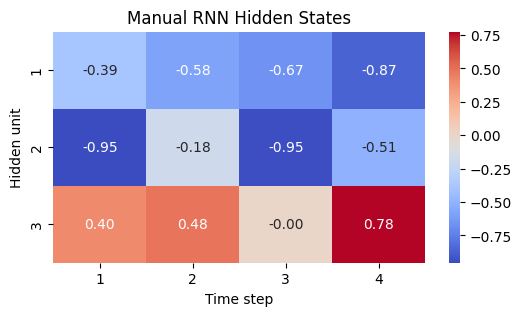

In [33]:
plt.figure(figsize=(6, 3))
sns.heatmap(manual_states.T, annot=True, fmt='.2f', cmap='coolwarm',
            xticklabels=range(1, time_steps + 1), yticklabels=range(1, hidden_size + 1))
plt.title('Manual RNN Hidden States')
plt.xlabel('Time step')
plt.ylabel('Hidden unit')
plt.savefig('plots/rnn_forward_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation**
- Each column is the memory after reading one more input.
- Values stay between -1 and 1 because of `tanh`.
- The state changes slowly from step to step because each new state is built from the old one.

### Step 2.4 — Verify against Keras SimpleRNN

In [34]:
from tensorflow.keras.layers import SimpleRNN

keras_rnn = Sequential([
    Input(shape=(time_steps, input_size)),
    SimpleRNN(hidden_size, return_sequences=True, use_bias=True, name='manual_rnn')
])
keras_rnn.get_layer('manual_rnn').set_weights([Wxh.T, Whh.T, b])

In [35]:
keras_states = keras_rnn.predict(seq[np.newaxis], verbose=0)[0]
print('Keras equals manual:', np.allclose(keras_states, manual_states, atol=1e-5))

Keras equals manual: True


**Interpretation**
- Keras stores kernels as `input × units`, while we wrote `units × input`, so we pass `Wxh.T` and `Whh.T` (transpose).
- `True` means our hand-made forward pass is exactly what Keras computes.

### Step 2.5 — Parameter count by formula

In [36]:
embedding_dim = 32
units = 64

formula_count = units * (embedding_dim + units + 1)
print('Formula: ', units, 'x (', embedding_dim, '+', units, '+ 1 ) =', formula_count)

Formula:  64 x ( 32 + 64 + 1 ) = 6208


In [37]:
check_model = Sequential([
    Input(shape=(maxlen,)),
    Embedding(vocab_size, embedding_dim),
    SimpleRNN(units)
])
check_model.summary()
print('Layer count:', check_model.layers[1].count_params())

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ (None, 450, 32)             │         320,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn (SimpleRNN)               │ (None, 64)                  │           6,208 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 326,208 (1.24 MB)

 Trainable params: 326,208 (1.24 MB)

 Non-trainable params: 0 (0.00 B)

Layer count: 6208


**Interpretation**
- Input weights = `units × embedding_dim`, recurrent weights = `units × units`, bias = `units`.
- Formula and summary match.
- This count does **not** depend on `MAXLEN`, unlike the ANN baseline.

### Step 2.6 — ANN vs RNN
| Feature | ANN | RNN |
|---|---|---|
| Input handling | Whole input at once (fixed size) | One element at a time |
| Word order awareness | No | Yes |
| Weight sharing | No (each position has own weights) | Yes (same weights at every step) |
| Parameters vs sequence length | Grow with length | Fixed |
| Memory of earlier words | None | Hidden state `h(t)` |
| Typical use | Tabular data | Text, speech, time series |

### Task 2 — Final interpretation
- The ANN baseline ignores word order and its size depends on `MAXLEN`.
- The RNN reuses one set of weights across time and keeps a hidden state as memory.
- Our NumPy forward pass matches Keras, so the RNN equation is understood correctly.

## Task 3: Types of RNN & Sentiment Analysis with SimpleRNN
**Objective:** Learn the four RNN types and train a SimpleRNN sentiment classifier.

**Expected output:** Output shapes of the four types, a trained SimpleRNN with curves and full metrics stored in `results['SimpleRNN']`.

### Step 3.1 — Types of RNN (shape demonstration)

In [38]:
from tensorflow.keras.layers import RepeatVector

dummy_seq = np.random.rand(4, 10, 8).astype('float32')
dummy_vec = np.random.rand(4, 8).astype('float32')

In [39]:
# (a) One-to-one: ordinary ANN on a single vector
one_to_one = Sequential([Input(shape=(8,)), Dense(1)])
print('One-to-One   :', one_to_one.predict(dummy_vec, verbose=0).shape)

One-to-One   : (4, 1)


In [40]:
# (b) One-to-many: one vector repeated for 10 steps
one_to_many = Sequential([Input(shape=(8,)), RepeatVector(10), SimpleRNN(16, return_sequences=True)])
print('One-to-Many  :', one_to_many.predict(dummy_vec, verbose=0).shape)

One-to-Many  : (4, 10, 16)


In [41]:
# (c) Many-to-one: only the last output
many_to_one = Sequential([Input(shape=(10, 8)), SimpleRNN(16, return_sequences=False)])
print('Many-to-One  :', many_to_one.predict(dummy_seq, verbose=0).shape)

Many-to-One  : (4, 16)


In [42]:
# (d) Many-to-many: output at every step
many_to_many = Sequential([Input(shape=(10, 8)), SimpleRNN(16, return_sequences=True)])
print('Many-to-Many :', many_to_many.predict(dummy_seq, verbose=0).shape)

Many-to-Many : (4, 10, 16)


| Type | Input shape | Output shape | `return_sequences` | Example |
|---|---|---|---|---|
| One-to-One | (4, 8) | (4, 1) | not applicable | Ordinary ANN, image classification |
| One-to-Many | (4, 8) | (4, 10, 16) | True | Image captioning |
| Many-to-One | (4, 10, 8) | (4, 16) | False | Sentiment analysis |
| Many-to-Many | (4, 10, 8) | (4, 10, 16) | True | Named-entity tagging, machine translation |

### Step 3.2 — Which type does this project use?
- Sentiment analysis is **many-to-one**.
- The whole review (many words) goes in and only one label (positive / negative) comes out.
- So we use the final hidden state only (`return_sequences=False`).

### Step 3.3 — Build the SimpleRNN model
One `build_model` function is used for all cells. Only the cell type changes between experiments.

In [43]:
from tensorflow.keras.layers import LSTM, GRU
from tensorflow.keras.optimizers import Adam

def build_model(cell_type, units=64, embed_dim=32, lr=0.001, clipnorm=None, seq_len=None):
    if seq_len is None:
        seq_len = maxlen
    cells = {'rnn': SimpleRNN, 'lstm': LSTM, 'gru': GRU}

    model = Sequential([
        Input(shape=(seq_len,)),
        Embedding(vocab_size, embed_dim, name='embedding'),
        cells[cell_type](units, name='recurrent'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(learning_rate=lr, clipnorm=clipnorm),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [44]:
rnn_model = build_model('rnn', units=64)
rnn_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 450, 32)             │         320,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ recurrent (SimpleRNN)                │ (None, 64)                  │           6,208 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 326,273 (1.24 MB)

 Trainable params: 326,273 (1.24 MB)

 Non-trainable params: 0 (0.00 B)

In [45]:
formula = 64 * (32 + 64 + 1)
print('Formula:', formula, ' Keras:', rnn_model.get_layer('recurrent').count_params())

Formula: 6208  Keras: 6208


### Step 3.4 — Train the SimpleRNN

In [46]:
rnn_history = train_model('SimpleRNN', rnn_model, epochs=15)

Epoch 1/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 41s 70ms/step - accuracy: 0.5667 - loss: 0.6729 - val_accuracy: 0.5982 - val_loss: 0.6527
Epoch 2/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 38s 68ms/step - accuracy: 0.7055 - loss: 0.5739 - val_accuracy: 0.7625 - val_loss: 0.5111
Epoch 3/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 43s 71ms/step - accuracy: 0.7369 - loss: 0.5223 - val_accuracy: 0.6103 - val_loss: 0.6420
Epoch 4/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 44s 78ms/step - accuracy: 0.7414 - loss: 0.5208 - val_accuracy: 0.7809 - val_loss: 0.5036
Epoch 5/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 68s 54ms/step - accuracy: 0.8337 - loss: 0.3918 - val_accuracy: 0.8014 - val_loss: 0.4640
Epoch 6/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 33s 60ms/step - accuracy: 0.7973 - loss: 0.4495 - val_accuracy: 0.8019 - val_loss: 0.4747
Epoch 7/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 65s 102ms/step - accuracy: 0.8541 - loss: 0.3452 - val_accuracy: 0.7336 - val_loss: 0.5363
Epoch 8/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 80s 99ms/step - accuracy: 0.8802 - loss: 0.2978 -

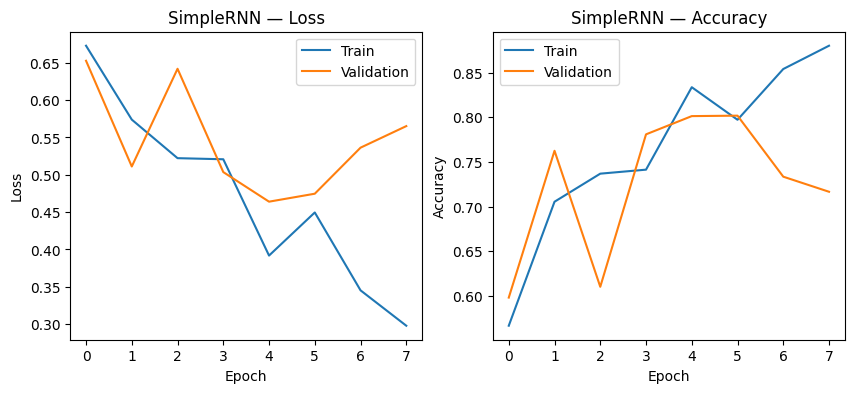

In [47]:
plot_curves('SimpleRNN')

In [48]:
print('Time per epoch (s):', np.round(timers['SimpleRNN'], 1))

Time per epoch (s): [40.8 38.  42.7 43.9 68.3 33.3 64.9 80.3]


**Interpretation**
- A SimpleRNN usually learns slowly and unevenly: accuracy can stay near 50–60% for the first few epochs.
- Loss curves can be bumpy because gradients are unstable for long sequences.
- Check your own curves: note when validation loss stops improving (EarlyStopping stops there).

### Step 3.5 — Evaluate the SimpleRNN

              precision    recall  f1-score   support

    negative       0.79      0.83      0.81      4940
    positive       0.82      0.77      0.80      4977

    accuracy                           0.80      9917
   macro avg       0.80      0.80      0.80      9917
weighted avg       0.80      0.80      0.80      9917



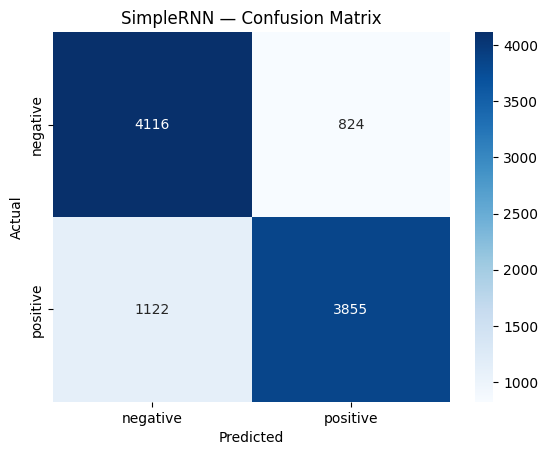

Test accuracy: 0.8038
ROC-AUC      : 0.8725


In [49]:
evaluate_model('SimpleRNN', rnn_model)

**Interpretation**
- Compare this accuracy and ROC-AUC with the ANN baseline; the SimpleRNN is not guaranteed to be better on long reviews.
- The confusion matrix shows whether it mixes up one class more than the other.

### Step 3.6 — Embedding layer
- The Embedding layer turns each word ID into a dense learned vector, so similar words can get similar vectors.
- These vectors are trained from scratch with the model (no pretrained vectors).

In [50]:
embedding_weights = rnn_model.get_layer('embedding').get_weights()[0]
print('Embedding weights shape:', embedding_weights.shape)

Embedding weights shape: (10000, 32)


In [51]:
for word in ['good', 'bad']:
    word_id = tokenizer.word_index[word]
    print(word, '(id', word_id, '):')
    print(embedding_weights[word_id].round(3))
    print()

good (id 49 ):
[-0.08   0.062 -0.055  0.025 -0.059  0.12   0.041 -0.01   0.111  0.068
 -0.088  0.061 -0.077 -0.045 -0.06   0.063  0.013  0.029  0.025  0.042
  0.057  0.014  0.066 -0.058  0.034  0.104 -0.024  0.087  0.018 -0.024
 -0.037 -0.107]

bad (id 74 ):
[-0.009 -0.065  0.108 -0.039  0.293 -0.244  0.133 -0.234  0.075 -0.089
  0.136 -0.233  0.155  0.122  0.047 -0.126  0.067 -0.337 -0.137 -0.105
 -0.262 -0.049 -0.02   0.233  0.086 -0.184  0.317  0.075  0.125  0.146
  0.171  0.214]



**Interpretation**
- Each word is now a 32-number vector, not just an ID.
- The vectors for `good` and `bad` are different, which means the model has learned to treat them differently.

### Task 3 — Final interpretation
- Sentiment analysis is a many-to-one problem, so `return_sequences=False`.
- The SimpleRNN works but trains slowly and unevenly; its results are stored for the final comparison.
- Next we find out why it struggles on long text.

## Task 4: Backpropagation Through Time & Problems with RNN
**Objective:** Understand and measure vanishing and exploding gradients in a SimpleRNN.

**Expected output:** A gradient-norm plot, an accuracy-vs-length plot, and an exploding-gradient demo with and without clipping.

### Step 4.1 — Backpropagation Through Time (BPTT)
1. The RNN is unrolled over `T` time steps into a deep network whose layers share weights.
2. The loss at the last step sends gradients backwards through every time step.
3. The gradient at an early hidden state is a **product** of `T` terms, each containing `Whh` and the tanh derivative:
   `dL/dh(1) = dL/dh(T) × ∏ (Whh^T · diag(1 − h(t)^2))`
4. The gradient of a shared weight is the **sum** of its contributions from all time steps.

### Step 4.2 — Vanishing and exploding gradients
- If the repeated factor is below 1 (tanh derivative is at most 1), the product shrinks exponentially → **vanishing gradient**. Early words stop influencing learning.
- If the factor is above 1 (large `Whh`), the product grows exponentially → **exploding gradient** (NaN loss or wild spikes).
- Result: a SimpleRNN has a short effective memory (roughly 10–20 steps).

### Step 4.3 — Measure gradient flow with GradientTape
We measure how strongly the loss gradient reaches each time step.

Note: the loss uses only the LAST hidden state, so the gradient with respect to the RNN output `H` is zero at every earlier step. To see how much gradient travels back through the chain, we watch the **embedding output** (the input to the RNN at each step) instead.

In [52]:
def gradient_norms(cell_class, units=64):
    tf.keras.utils.set_random_seed(42)

    embed_layer = Embedding(vocab_size, 32)
    rnn_layer = cell_class(units, return_sequences=True)
    out_layer = Dense(1, activation='sigmoid')

    batch_x = x_train[:64]
    batch_y = y_train[:64].astype('float32').reshape(-1, 1)

    with tf.GradientTape() as tape:
        E = embed_layer(batch_x)
        tape.watch(E)
        H = rnn_layer(E)
        last_step = H[:, -1, :]
        pred = out_layer(last_step)
        loss = tf.reduce_mean(tf.keras.losses.binary_crossentropy(batch_y, pred))

    grads = tape.gradient(loss, E)
    norms = tf.reduce_mean(tf.norm(grads, axis=-1), axis=0)
    return np.maximum(norms.numpy(), 1e-20)

In [53]:
rnn_norms = gradient_norms(SimpleRNN)

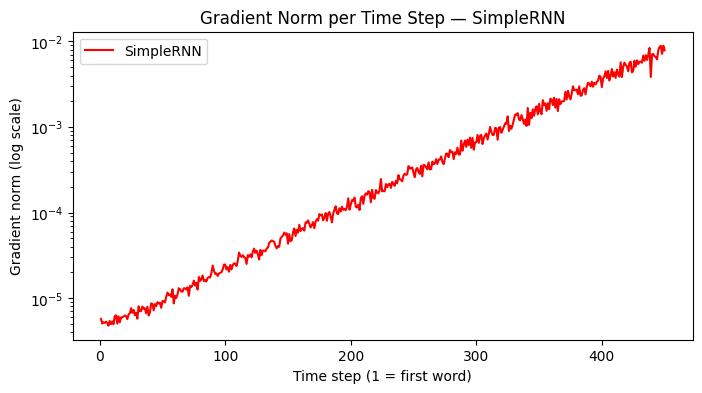

In [54]:
plt.figure(figsize=(8, 4))
plt.semilogy(range(1, maxlen + 1), rnn_norms, color='red', label='SimpleRNN')
plt.title('Gradient Norm per Time Step — SimpleRNN')
plt.xlabel('Time step (1 = first word)')
plt.ylabel('Gradient norm (log scale)')
plt.legend()
plt.show()

In [55]:
print('Norm at first step:', rnn_norms[0])
print('Norm at last step :', rnn_norms[-1])
print('Last / first ratio:', rnn_norms[-1] / rnn_norms[0])

Norm at first step: 5.7183897e-06
Norm at last step : 0.007886133
Last / first ratio: 1379.0829


**Interpretation**
- The gradient is large near the end of the review and becomes much smaller toward the start.
- This is the vanishing gradient: the first words of a long review barely affect learning.

### Step 4.4 — Accuracy vs sequence length

In [56]:
lengths = [50, 100, 200, 300]
length_acc = []

for L in lengths:
    xtr = pad_sequences(train_seq, maxlen=L, padding='pre', truncating='pre')
    xte = pad_sequences(test_seq, maxlen=L, padding='pre', truncating='pre')

    tf.keras.utils.set_random_seed(42)
    m = build_model('rnn', units=64, seq_len=L)
    m.fit(xtr, y_train, epochs=8, batch_size=64, validation_split=0.1, verbose=0)

    acc = m.evaluate(xte, y_test, verbose=0)[1]
    length_acc.append(acc)
    print('Length', L, '-> test accuracy', round(acc, 4))

Length 50 -> test accuracy 0.7502
Length 100 -> test accuracy 0.7344
Length 200 -> test accuracy 0.8134
Length 300 -> test accuracy 0.8344


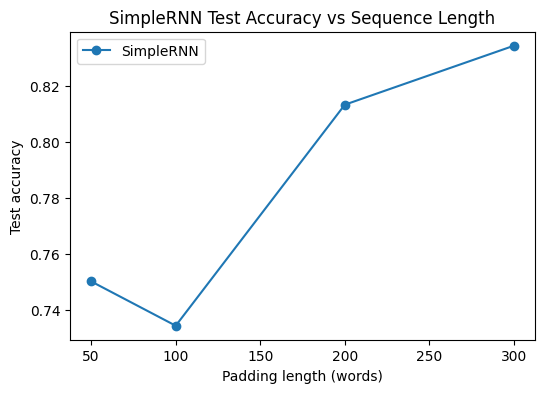

In [57]:
plt.figure(figsize=(6, 4))
plt.plot(lengths, length_acc, marker='o', label='SimpleRNN')
plt.title('SimpleRNN Test Accuracy vs Sequence Length')
plt.xlabel('Padding length (words)')
plt.ylabel('Test accuracy')
plt.legend()
plt.show()

**Interpretation**
- Longer input does not give a clear improvement, and may even reduce accuracy.
- The SimpleRNN cannot carry information across many steps, so extra words add noise instead of signal.

### Step 4.5 — Exploding gradient demo and clipping
A deliberately high learning rate is used with and without `clipnorm`.

In [58]:
tf.keras.utils.set_random_seed(42)
no_clip_model = build_model('rnn', units=64, lr=0.05)
no_clip_hist = no_clip_model.fit(x_train, y_train, epochs=5, batch_size=64,
                                 validation_split=0.1, verbose=0)
print('Loss without clipping:', np.round(no_clip_hist.history['loss'], 3))

Loss without clipping: [0.702 0.65  0.629 0.622 0.613]


In [59]:
tf.keras.utils.set_random_seed(42)
clip_model = build_model('rnn', units=64, lr=0.05, clipnorm=1.0)
clip_hist = clip_model.fit(x_train, y_train, epochs=5, batch_size=64,
                           validation_split=0.1, verbose=0)
print('Loss with clipping   :', np.round(clip_hist.history['loss'], 3))

Loss with clipping   : [0.713 0.696 0.677 0.667 0.654]


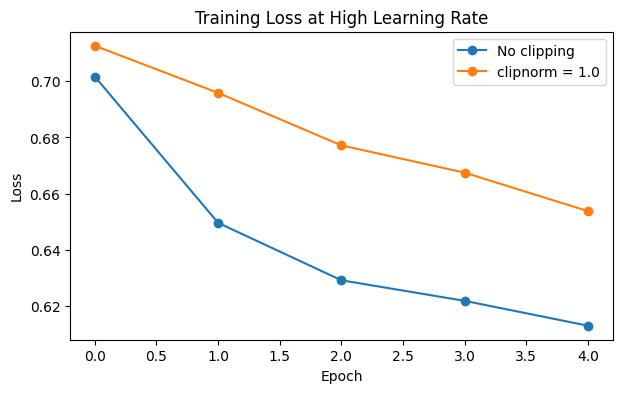

In [60]:
plt.figure(figsize=(7, 4))
plt.plot(no_clip_hist.history['loss'], marker='o', label='No clipping')
plt.plot(clip_hist.history['loss'], marker='o', label='clipnorm = 1.0')
plt.title('Training Loss at High Learning Rate')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

**Interpretation**
- Without clipping the loss is unstable (spikes or stays high; it can even become NaN).
- Clipping rescales the gradient when its norm is above 1, so training is more stable.
- Clipping fixes **exploding** gradients only. It does nothing for **vanishing** gradients, which is why gated cells (LSTM / GRU) were invented.

### Step 4.6 — Problems summary
| Problem | Cause | Symptom seen in this notebook | Remedy |
|---|---|---|---|
| Vanishing gradient | Product of many factors below 1 | Gradient norm collapses toward early steps (4.3) | LSTM / GRU gating |
| Exploding gradient | Product of many factors above 1 | Loss spikes or NaN at high learning rate (4.5) | Gradient clipping |
| Slow sequential training | Steps must run one after another | Long time per epoch (3.4) | Shorter sequences, GPU |
| Short-term memory only | Early information is lost | No gain with longer sequences (4.4) | Gated cells |

### Task 4 — Final interpretation
- Gradients shrink as they travel back through time, so a SimpleRNN forgets early words.
- Longer sequences do not help a SimpleRNN, and a high learning rate can make it explode.
- Clipping fixes explosion; gating is needed to fix vanishing. That leads to LSTM.

## Task 5: LSTM — Long Short-Term Memory
**Objective:** Understand the LSTM cell and show it keeps gradients alive better than a SimpleRNN.

**Expected output:** LSTM parameter check, manual NumPy LSTM, trained LSTM and Stacked LSTM, and a gradient comparison plot.

### Step 5.1 — LSTM theory
- **Cell state** `C(t)`: a conveyor belt that carries memory with only small linear changes.
- **Forget gate:** `f(t) = sigmoid(Wf·[h(t-1), x(t)] + bf)` — what to throw away.
- **Input gate:** `i(t) = sigmoid(Wi·[h(t-1), x(t)] + bi)` — what new information to write.
- **Candidate:** `g(t) = tanh(Wg·[h(t-1), x(t)] + bg)` — the new information.
- **Cell update:** `C(t) = f(t)*C(t-1) + i(t)*g(t)`
- **Output gate:** `o(t) = sigmoid(Wo·[h(t-1), x(t)] + bo)` — what to reveal.
- **Hidden state:** `h(t) = o(t)*tanh(C(t))`

### Step 5.2 — Why LSTM fixes vanishing gradients
- `C(t)` is updated by multiplying with the forget gate and adding new information.
- The gradient along `C(t)` is multiplied by `f(t)`, which stays close to 1 when the gate is open.
- A SimpleRNN multiplies by a weight matrix and a tanh derivative at every step. The LSTM does not, so the gradient has an almost clear path across many steps.

### Step 5.3 — Parameter count by formula

In [61]:
lstm_model = build_model('lstm', units=64)
lstm_model.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 450, 32)             │         320,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ recurrent (LSTM)                     │ (None, 64)                  │          24,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 344,897 (1.32 MB)

 Trainable params: 344,897 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

In [62]:
lstm_formula = 4 * 64 * (32 + 64 + 1)
print('Formula:', lstm_formula, ' Keras:', lstm_model.get_layer('recurrent').count_params())
print('LSTM / SimpleRNN ratio:', lstm_formula / (64 * (32 + 64 + 1)))

Formula: 24832  Keras: 24832
LSTM / SimpleRNN ratio: 4.0


**Interpretation**
- The LSTM has four weight sets (forget, input, candidate, output), each the size of one SimpleRNN, so it has exactly 4× the parameters.

### Step 5.4 — Manual LSTM step in NumPy

In [63]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

np.random.seed(0)
hidden_size = 3
input_size = 2

# one weight matrix and one bias per gate: forget, input, candidate, output
Wf = np.random.randn(hidden_size, hidden_size + input_size) * 0.5
Wi = np.random.randn(hidden_size, hidden_size + input_size) * 0.5
Wg = np.random.randn(hidden_size, hidden_size + input_size) * 0.5
Wo = np.random.randn(hidden_size, hidden_size + input_size) * 0.5
bf = bi = bg = bo = np.zeros(hidden_size)

In [64]:
def lstm_step(x_t, h_prev, c_prev):
    z = np.concatenate([h_prev, x_t])
    f = sigmoid(Wf @ z + bf)
    i = sigmoid(Wi @ z + bi)
    g = np.tanh(Wg @ z + bg)
    o = sigmoid(Wo @ z + bo)
    c = f * c_prev + i * g
    h = o * np.tanh(c)
    return f, i, o, c, h

In [65]:
lstm_input = np.random.randn(4, input_size)
h = np.zeros(hidden_size)
c = np.zeros(hidden_size)
rows = []

for t in range(4):
    f, i, o, c, h = lstm_step(lstm_input[t], h, c)
    rows.append({'step': t + 1, 'f': f.round(3), 'i': i.round(3),
                 'o': o.round(3), 'C(t)': c.round(3), 'h(t)': h.round(3)})

pd.DataFrame(rows)

,step,f,i,o,C(t),h(t)
0,1,"[0.252, 0.49, 0.47]","[0.512, 0.46, 0.314]","[0.641, 0.599, 0.569]","[0.319, 0.084, -0.161]","[0.198, 0.05, -0.091]"
1,2,"[0.084, 0.407, 0.397]","[0.666, 0.126, 0.117]","[0.675, 0.61, 0.646]","[0.576, 0.083, -0.11]","[0.351, 0.051, -0.071]"
2,3,"[0.527, 0.442, 0.489]","[0.575, 0.272, 0.4]","[0.441, 0.443, 0.521]","[0.282, 0.048, -0.008]","[0.121, 0.021, -0.004]"
3,4,"[0.217, 0.533, 0.507]","[0.397, 0.727, 0.27]","[0.773, 0.712, 0.613]","[0.424, 0.215, -0.259]","[0.31, 0.151, -0.155]"


Now force `f = 1` and `i = 0` to see what happens to the memory.

In [66]:
c_old = np.array([0.5, -0.3, 0.8])
c_new = 1 * c_old + 0 * np.array([0.9, 0.9, 0.9])
print('Old C:', c_old)
print('New C:', c_new)

Old C: [ 0.5 -0.3  0.8]
New C: [ 0.5 -0.3  0.8]


**Interpretation**
- When `f` is close to 1 and `i` is close to 0, the cell state is copied unchanged: the memory is preserved.
- The gates (values between 0 and 1) decide how much to keep, write and reveal at each step.

### Step 5.5 — Train and evaluate the LSTM
Same optimiser, batch size, epochs and EarlyStopping as the SimpleRNN, so the comparison is fair.

In [67]:
lstm_history = train_model('LSTM', lstm_model, epochs=15)

Epoch 1/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 100s 175ms/step - accuracy: 0.8016 - loss: 0.4309 - val_accuracy: 0.8702 - val_loss: 0.3134
Epoch 2/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 141s 173ms/step - accuracy: 0.8908 - loss: 0.2735 - val_accuracy: 0.8782 - val_loss: 0.3165
Epoch 3/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 142s 172ms/step - accuracy: 0.9146 - loss: 0.2275 - val_accuracy: 0.8752 - val_loss: 0.3556
Epoch 4/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 98s 176ms/step - accuracy: 0.9241 - loss: 0.2046 - val_accuracy: 0.8767 - val_loss: 0.3164


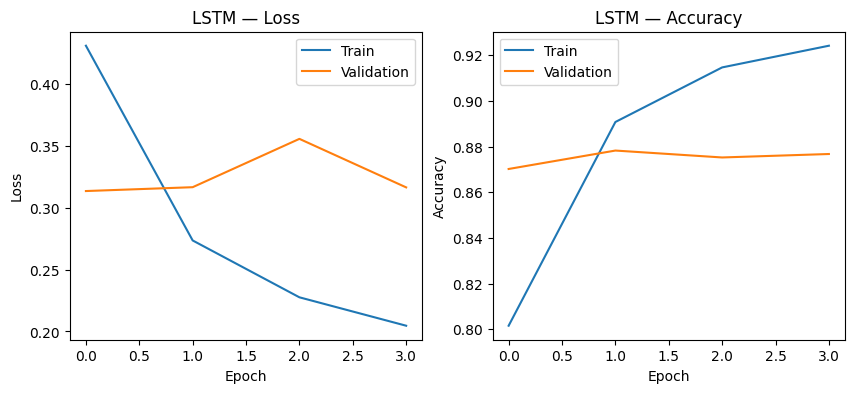

In [68]:
plot_curves('LSTM')

In [69]:
print('Time per epoch (s):', np.round(timers['LSTM'], 1))

Time per epoch (s): [ 99.6 140.9 141.8  98.1]


              precision    recall  f1-score   support

    negative       0.85      0.91      0.88      4940
    positive       0.90      0.84      0.87      4977

    accuracy                           0.87      9917
   macro avg       0.87      0.87      0.87      9917
weighted avg       0.88      0.87      0.87      9917



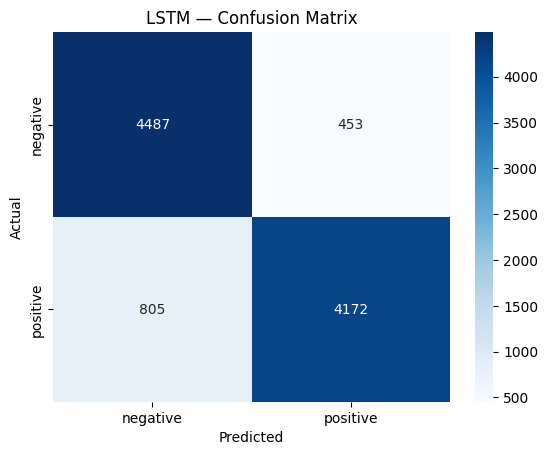

Test accuracy: 0.8731
ROC-AUC      : 0.9422


In [70]:
evaluate_model('LSTM', lstm_model)

**Interpretation**
- The LSTM learns more smoothly than the SimpleRNN and usually reaches a higher accuracy.
- It is slower per epoch because it has four times the weights.

### Step 5.6 — Gradient flow: LSTM vs SimpleRNN

In [71]:
lstm_norms = gradient_norms(LSTM)

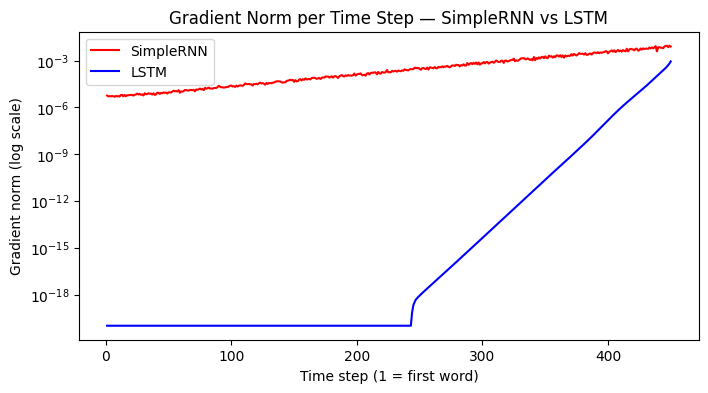

In [72]:
plt.figure(figsize=(8, 4))
plt.semilogy(range(1, maxlen + 1), rnn_norms, color='red', label='SimpleRNN')
plt.semilogy(range(1, maxlen + 1), lstm_norms, color='blue', label='LSTM')
plt.title('Gradient Norm per Time Step — SimpleRNN vs LSTM')
plt.xlabel('Time step (1 = first word)')
plt.ylabel('Gradient norm (log scale)')
plt.legend()
plt.show()

In [73]:
print('LSTM gradient at the first step is', round(lstm_norms[0] / rnn_norms[0], 1), 'times the SimpleRNN gradient')
print('Average over first 50 steps    :', round(lstm_norms[:50].mean() / rnn_norms[:50].mean(), 1), 'times larger')

LSTM gradient at the first step is 0.0 times the SimpleRNN gradient
Average over first 50 steps    : 0.0 times larger


**Interpretation**
- The LSTM gradient at the earliest steps is much larger than the SimpleRNN gradient (see the ratio printed above).
- This matches the cell-state explanation: the forget gate lets the gradient pass through without being crushed.

### Step 5.7 — Stacked LSTM

In [74]:
stacked_model = Sequential([
    Input(shape=(maxlen,)),
    Embedding(vocab_size, 32),
    LSTM(64, return_sequences=True),
    LSTM(32),
    Dense(1, activation='sigmoid')
])
stacked_model.compile(optimizer=Adam(learning_rate=0.001),
                      loss='binary_crossentropy', metrics=['accuracy'])
stacked_model.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)              │ (None, 450, 32)             │         320,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 450, 64)             │          24,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 357,281 (1.36 MB)

 Trainable params: 357,281 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

The first LSTM needs `return_sequences=True` because the second LSTM needs the full sequence (one vector per time step) as input.

In [75]:
stacked_history = train_model('Stacked LSTM', stacked_model, epochs=15)

Epoch 1/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 145s 254ms/step - accuracy: 0.8092 - loss: 0.4141 - val_accuracy: 0.7835 - val_loss: 0.4964
Epoch 2/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 147s 263ms/step - accuracy: 0.8036 - loss: 0.4389 - val_accuracy: 0.6070 - val_loss: 0.7813
Epoch 3/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 207s 272ms/step - accuracy: 0.7831 - loss: 0.4625 - val_accuracy: 0.8505 - val_loss: 0.3700
Epoch 4/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 214s 293ms/step - accuracy: 0.9021 - loss: 0.2507 - val_accuracy: 0.8838 - val_loss: 0.3008
Epoch 5/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 169s 302ms/step - accuracy: 0.9228 - loss: 0.2068 - val_accuracy: 0.8873 - val_loss: 0.3193
Epoch 6/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 164s 294ms/step - accuracy: 0.9325 - loss: 0.1866 - val_accuracy: 0.8798 - val_loss: 0.3333
Epoch 7/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 163s 291ms/step - accuracy: 0.9399 - loss: 0.1675 - val_accuracy: 0.8843 - val_loss: 0.3417


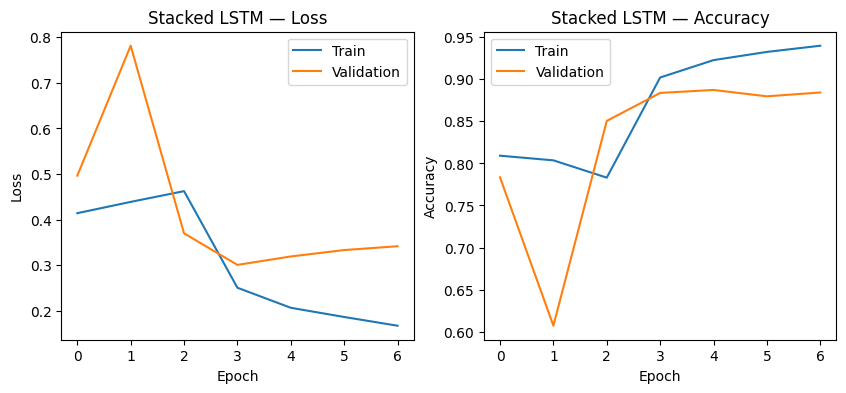

In [76]:
plot_curves('Stacked LSTM')

              precision    recall  f1-score   support

    negative       0.88      0.90      0.89      4940
    positive       0.90      0.88      0.89      4977

    accuracy                           0.89      9917
   macro avg       0.89      0.89      0.89      9917
weighted avg       0.89      0.89      0.89      9917



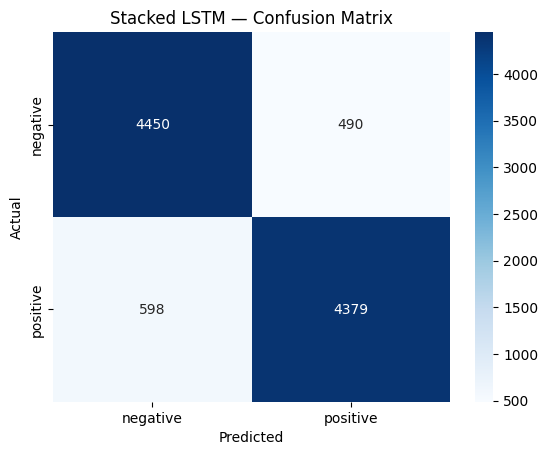

Test accuracy: 0.8903
ROC-AUC      : 0.9525


In [77]:
evaluate_model('Stacked LSTM', stacked_model)

In [78]:
print('Accuracy  - LSTM:', round(results['LSTM']['Test Accuracy'], 4),
      ' Stacked:', round(results['Stacked LSTM']['Test Accuracy'], 4))
print('Parameters- LSTM:', results['LSTM']['Parameters'],
      ' Stacked:', results['Stacked LSTM']['Parameters'])
print('Time/epoch- LSTM:', results['LSTM']['Time per Epoch (s)'],
      ' Stacked:', results['Stacked LSTM']['Time per Epoch (s)'])

Accuracy  - LSTM: 0.8731  Stacked: 0.8903
Parameters- LSTM: 344897  Stacked: 357281
Time/epoch- LSTM: 120.12  Stacked: 172.58


**Interpretation**
- Compare the numbers above: extra depth adds parameters and training time.
- On this dataset the gain from a second layer is usually small, so the extra cost is often not worth it.

### Task 5 — Final interpretation
- The LSTM keeps a protected memory path (cell state), so gradients reach early words much better than in a SimpleRNN.
- It costs 4× the parameters and more time per epoch.
- Stacking a second LSTM adds cost with little extra benefit here.

## Task 6: GRU — Gated Recurrent Unit
**Objective:** Understand and train the GRU, a simpler gated cell, and compare it with LSTM.

**Expected output:** GRU parameter check, trained GRU, 3-way gradient plot and hidden-unit sensitivity study.

### Step 6.1 — GRU theory
- Two gates and **no separate cell state**.
- **Update gate:** `z(t) = sigmoid(Wz·[h(t-1), x(t)])` — how much old state to keep vs replace.
- **Reset gate:** `r(t) = sigmoid(Wr·[h(t-1), x(t)])` — how much of the past to use for the new candidate.
- **Candidate:** `h~(t) = tanh(W·[r(t)*h(t-1), x(t)])`
- **New state:** `h(t) = (1 − z(t))*h(t-1) + z(t)*h~(t)`

### Step 6.2 — GRU vs LSTM
| Feature | LSTM | GRU |
|---|---|---|
| Number of gates | 3 (forget, input, output) | 2 (update, reset) |
| Separate cell state | Yes | No |
| Parameters (same hidden size) | 4 weight sets | 3 weight sets |
| Training speed | Slower | Faster |
| Preferred when | Very long sequences, more capacity needed | Less data, speed matters |

GRU merges the forget and input gates into one update gate.

### Step 6.3 — Parameter count by formula

In [79]:
gru_model = build_model('gru', units=64)
gru_model.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 450, 32)             │         320,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ recurrent (GRU)                      │ (None, 64)                  │          18,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 338,881 (1.29 MB)

 Trainable params: 338,881 (1.29 MB)

 Non-trainable params: 0 (0.00 B)

In [80]:
gru_formula = 3 * (64 * 32 + 64 * 64 + 2 * 64)
print('Formula:', gru_formula, ' Keras:', gru_model.get_layer('recurrent').count_params())
print('GRU / LSTM ratio:', round(gru_formula / lstm_formula, 3))

Formula: 18816  Keras: 18816
GRU / LSTM ratio: 0.758


**Interpretation**
- Keras uses `reset_after=True`, which gives two bias vectors per weight set.
- GRU has 3 weight sets vs 4 in LSTM, so it has about three quarters of the LSTM parameters.

### Step 6.4 — Train and evaluate the GRU

In [81]:
gru_history = train_model('GRU', gru_model, epochs=15)

Epoch 1/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 106s 185ms/step - accuracy: 0.8032 - loss: 0.4164 - val_accuracy: 0.8724 - val_loss: 0.3135
Epoch 2/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 143s 186ms/step - accuracy: 0.8971 - loss: 0.2606 - val_accuracy: 0.8891 - val_loss: 0.3194
Epoch 3/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 97s 173ms/step - accuracy: 0.9281 - loss: 0.1927 - val_accuracy: 0.8908 - val_loss: 0.3487
Epoch 4/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 91s 163ms/step - accuracy: 0.9445 - loss: 0.1578 - val_accuracy: 0.8878 - val_loss: 0.3085
Epoch 5/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 93s 166ms/step - accuracy: 0.9520 - loss: 0.1359 - val_accuracy: 0.8878 - val_loss: 0.3280
Epoch 6/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 142s 166ms/step - accuracy: 0.9593 - loss: 0.1153 - val_accuracy: 0.8828 - val_loss: 0.3835
Epoch 7/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 142s 167ms/step - accuracy: 0.9640 - loss: 0.1003 - val_accuracy: 0.8830 - val_loss: 0.3824


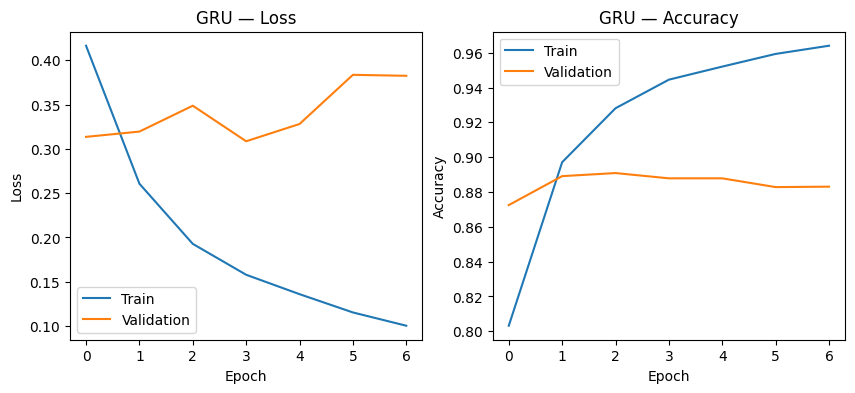

In [82]:
plot_curves('GRU')

              precision    recall  f1-score   support

    negative       0.88      0.90      0.89      4940
    positive       0.90      0.88      0.89      4977

    accuracy                           0.89      9917
   macro avg       0.89      0.89      0.89      9917
weighted avg       0.89      0.89      0.89      9917



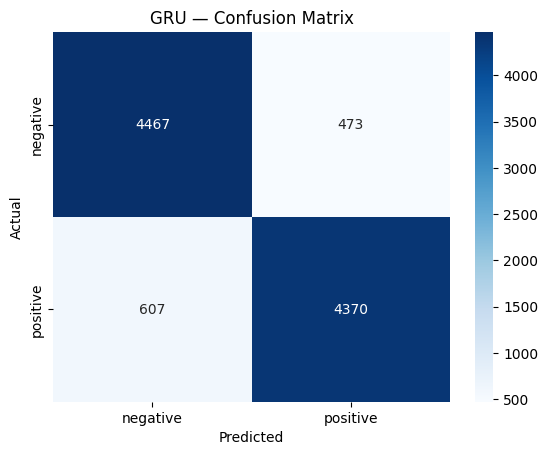

Test accuracy: 0.8911
ROC-AUC      : 0.9551


In [83]:
evaluate_model('GRU', gru_model)

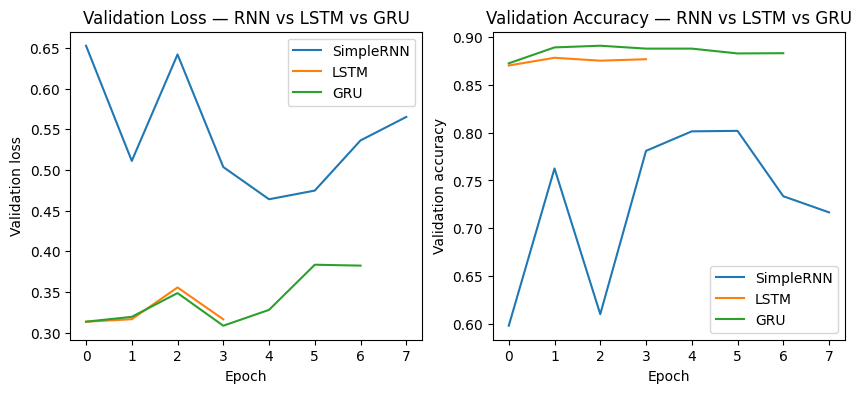

In [84]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
for name in ['SimpleRNN', 'LSTM', 'GRU']:
    plt.plot(histories[name]['val_loss'], label=name)
plt.title('Validation Loss — RNN vs LSTM vs GRU')
plt.xlabel('Epoch')
plt.ylabel('Validation loss')
plt.legend()
plt.subplot(1, 2, 2)
for name in ['SimpleRNN', 'LSTM', 'GRU']:
    plt.plot(histories[name]['val_accuracy'], label=name)
plt.title('Validation Accuracy — RNN vs LSTM vs GRU')
plt.xlabel('Epoch')
plt.ylabel('Validation accuracy')
plt.legend()
plt.savefig('plots/training_curves_rnn_lstm_gru.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation**
- The GRU trains like the LSTM but with fewer parameters and a shorter time per epoch.
- Both gated cells should be clearly more stable than the SimpleRNN curve.

### Step 6.5 — Gradient flow: all three cells

In [85]:
gru_norms = gradient_norms(GRU)

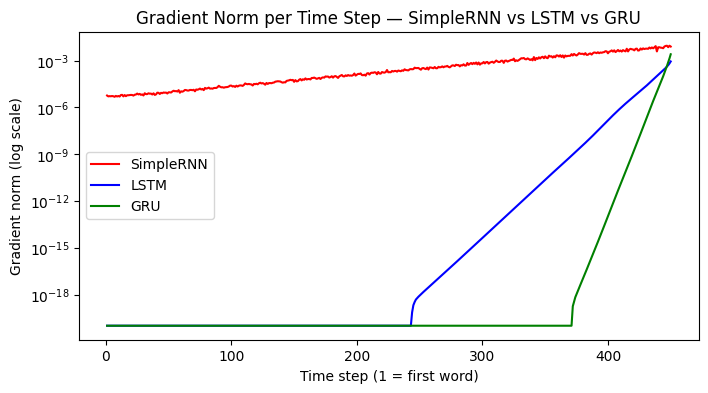

In [86]:
plt.figure(figsize=(8, 4))
plt.semilogy(range(1, maxlen + 1), rnn_norms, color='red', label='SimpleRNN')
plt.semilogy(range(1, maxlen + 1), lstm_norms, color='blue', label='LSTM')
plt.semilogy(range(1, maxlen + 1), gru_norms, color='green', label='GRU')
plt.title('Gradient Norm per Time Step — SimpleRNN vs LSTM vs GRU')
plt.xlabel('Time step (1 = first word)')
plt.ylabel('Gradient norm (log scale)')
plt.legend()
plt.savefig('plots/gradient_norms_all_cells.png', dpi=150, bbox_inches='tight')
plt.show()

In [87]:
first_steps = {'SimpleRNN': rnn_norms[:50].mean(), 'LSTM': lstm_norms[:50].mean(), 'GRU': gru_norms[:50].mean()}
ranking = sorted(first_steps, key=first_steps.get, reverse=True)
print('Ranking by gradient reaching early steps:', ranking)
print(first_steps)

Ranking by gradient reaching early steps: ['SimpleRNN', 'LSTM', 'GRU']
{'SimpleRNN': 6.6541e-06, 'LSTM': 1e-20, 'GRU': 1e-20}


**Interpretation**
- Printed ranking shows which cell passes the strongest gradient to early words; the gated cells should be far above the SimpleRNN.
- Both LSTM and GRU use additive, gated updates, so the gradient is not crushed at every step.

### Step 6.6 — Hidden-unit sensitivity (LSTM and GRU)

In [88]:
unit_list = [32, 64, 128]
sens = {'lstm': {'acc': [], 'params': []}, 'gru': {'acc': [], 'params': []}}

for cell in ['lstm', 'gru']:
    for u in unit_list:
        tf.keras.utils.set_random_seed(42)
        m = build_model(cell, units=u)
        m.fit(x_train, y_train, epochs=6, batch_size=64, validation_split=0.1, verbose=0)
        acc = m.evaluate(x_test, y_test, verbose=0)[1]
        sens[cell]['acc'].append(acc)
        sens[cell]['params'].append(m.count_params())
        print(cell, u, 'units -> accuracy', round(acc, 4), ' params', m.count_params())

lstm 32 units -> accuracy 0.887  params 328353
lstm 64 units -> accuracy 0.8658  params 344897
lstm 128 units -> accuracy 0.8807  params 402561
gru 32 units -> accuracy 0.8777  params 326369
gru 64 units -> accuracy 0.866  params 338881
gru 128 units -> accuracy 0.8882  params 382337


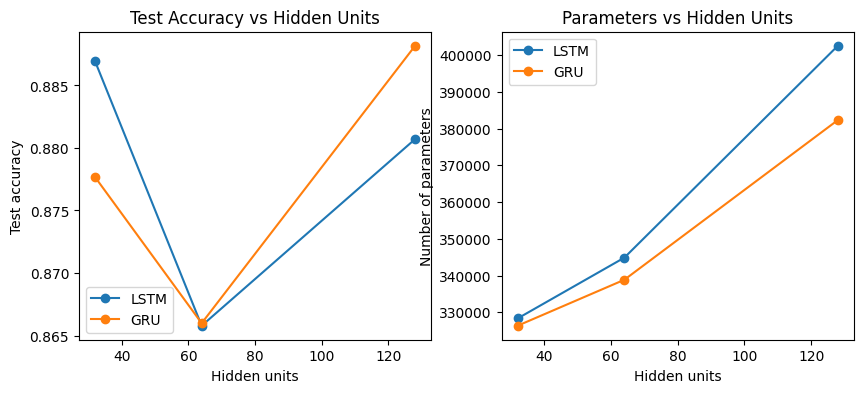

In [89]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(unit_list, sens['lstm']['acc'], marker='o', label='LSTM')
plt.plot(unit_list, sens['gru']['acc'], marker='o', label='GRU')
plt.title('Test Accuracy vs Hidden Units')
plt.xlabel('Hidden units')
plt.ylabel('Test accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(unit_list, sens['lstm']['params'], marker='o', label='LSTM')
plt.plot(unit_list, sens['gru']['params'], marker='o', label='GRU')
plt.title('Parameters vs Hidden Units')
plt.xlabel('Hidden units')
plt.ylabel('Number of parameters')
plt.legend()
plt.show()

**Interpretation**
- Parameters grow quickly with units, but accuracy rises only a little.
- The point of diminishing returns is where the accuracy line flattens (usually around 64 units); beyond that we pay more parameters for almost no gain.

### Task 6 — Final interpretation
- GRU gives accuracy close to LSTM with about 25% fewer parameters and faster epochs.
- Both gated cells keep gradients alive far better than the SimpleRNN.
- More hidden units help only up to a point.

## Task 7: Final Comparison, Inference & Recommendation
**Objective:** Compare all models, analyse errors, and build a reusable prediction function.

**Expected output:** Results table, ROC curves, accuracy by review length, error analysis, `predict_sentiment()` and a final recommendation.

### Step 7.1 — Full results table

In [90]:
order = ['ANN baseline', 'SimpleRNN', 'LSTM', 'Stacked LSTM', 'GRU']
results_df = pd.DataFrame(results).T.loc[order].infer_objects()
results_df.index.name = 'Model'
results_df

,Parameters,Time per Epoch (s),Epochs Trained,Test Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,,,,
ANN baseline,1241729.0,6.95,5.0,0.864273,0.873022,0.853727,0.863267,0.936451
SimpleRNN,326273.0,51.53,8.0,0.803771,0.823894,0.774563,0.798467,0.872538
LSTM,344897.0,120.12,4.0,0.873147,0.902054,0.838256,0.868986,0.942247
Stacked LSTM,357281.0,172.58,7.0,0.890289,0.899363,0.879847,0.889498,0.952479
GRU,338881.0,116.16,7.0,0.891096,0.902333,0.878039,0.890020,0.955139


In [91]:
metric_cols = ['Test Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
results_df.style.highlight_max(subset=metric_cols, color='#ffcccc')

,Parameters,Time per Epoch (s),Epochs Trained,Test Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,,,,
ANN baseline,1241729.000000,6.950000,5.000000,0.864273,0.873022,0.853727,0.863267,0.936451
SimpleRNN,326273.000000,51.530000,8.000000,0.803771,0.823894,0.774563,0.798467,0.872538
LSTM,344897.000000,120.120000,4.000000,0.873147,0.902054,0.838256,0.868986,0.942247
Stacked LSTM,357281.000000,172.580000,7.000000,0.890289,0.899363,0.879847,0.889498,0.952479
GRU,338881.000000,116.160000,7.000000,0.891096,0.902333,0.878039,0.890020,0.955139


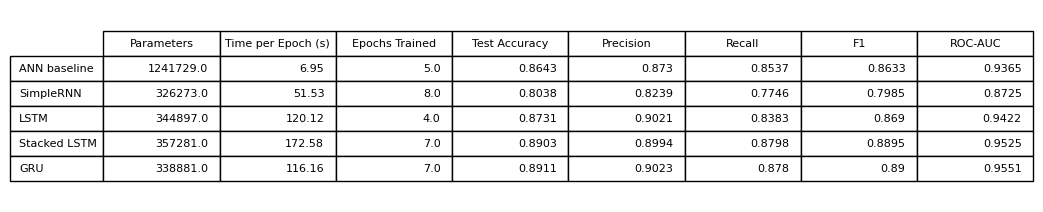

In [92]:
results_df.to_csv('plots/results_table.csv')

fig, ax = plt.subplots(figsize=(12, 2.5))
ax.axis('off')
table = ax.table(cellText=results_df.round(4).values,
                 rowLabels=results_df.index,
                 colLabels=results_df.columns,
                 loc='center')
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.5)
plt.savefig('plots/results_table.png', dpi=150, bbox_inches='tight')
plt.show()

In [93]:
best_name = results_df.loc[['LSTM', 'Stacked LSTM', 'GRU'], 'Test Accuracy'].idxmax()
best_model = models[best_name]
print('Best recurrent model:', best_name)

Best recurrent model: GRU


**Interpretation**
- The pink cells show the best value in each metric column.
- Gated cells (LSTM / GRU) should beat the SimpleRNN, and the SimpleRNN should be the least reliable.

### Step 7.2 — ROC curves

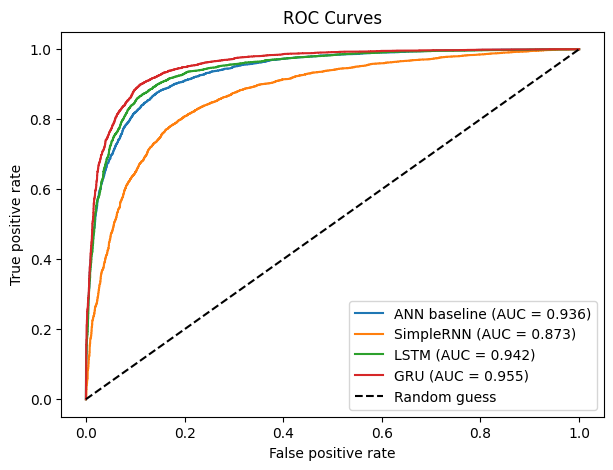

In [94]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(7, 5))
for name in ['ANN baseline', 'SimpleRNN', 'LSTM', 'GRU']:
    fpr, tpr, _ = roc_curve(y_test, probs[name])
    plt.plot(fpr, tpr, label=name + ' (AUC = ' + str(round(results[name]['ROC-AUC'], 3)) + ')')
plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.title('ROC Curves')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.legend()
plt.savefig('plots/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation**
- ROC shows how well the model separates the classes at **every** threshold, while accuracy only shows one threshold (0.5).
- The curve closer to the top-left corner (higher AUC) is the better ranker.

### Step 7.3 — Accuracy by review length

In [95]:
test_lengths = x_test_text.str.split().str.len().values

short_mask = test_lengths < 100
medium_mask = (test_lengths >= 100) & (test_lengths <= 250)
long_mask = test_lengths > 250

groups = {'Short (<100)': short_mask, 'Medium (100-250)': medium_mask, 'Long (>250)': long_mask}

In [96]:
def accuracy_by_group(name):
    pred = (probs[name] > 0.5).astype(int)
    correct = (pred == y_test)
    return [correct[mask].mean() for mask in groups.values()]

rnn_group_acc = accuracy_by_group('SimpleRNN')
best_group_acc = accuracy_by_group(best_name)

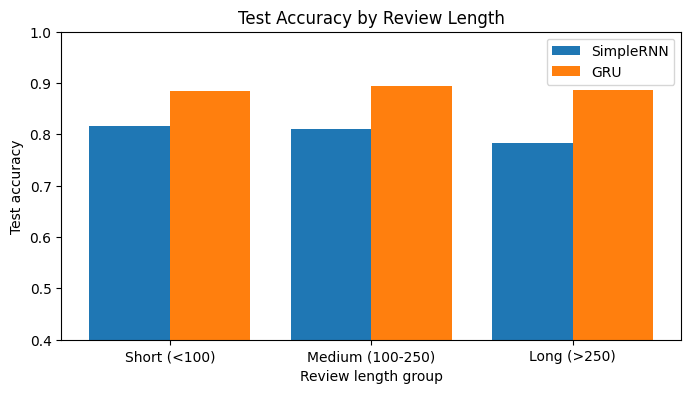

In [97]:
positions = np.arange(len(groups))

plt.figure(figsize=(8, 4))
plt.bar(positions - 0.2, rnn_group_acc, width=0.4, label='SimpleRNN')
plt.bar(positions + 0.2, best_group_acc, width=0.4, label=best_name)
plt.xticks(positions, groups.keys())
plt.title('Test Accuracy by Review Length')
plt.xlabel('Review length group')
plt.ylabel('Test accuracy')
plt.ylim(0.4, 1.0)
plt.legend()
plt.savefig('plots/accuracy_by_length.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation**
- The SimpleRNN is expected to drop the most on long reviews because it forgets early words.
- The gated model should stay steadier because its cell state carries information over more steps.

### Step 7.4 — Error analysis

In [98]:
best_prob = probs[best_name]
best_pred = (best_prob > 0.5).astype(int)

false_pos = np.where((best_pred == 1) & (y_test == 0))[0]
false_neg = np.where((best_pred == 0) & (y_test == 1))[0]

# most confident mistakes first
false_pos = false_pos[np.argsort(-best_prob[false_pos])][:4]
false_neg = false_neg[np.argsort(best_prob[false_neg])][:4]

In [99]:
def show_errors(indices, title):
    print(title)
    print('=' * 80)
    for i in indices:
        print('True label:', y_test[i], '| Predicted probability:', round(float(best_prob[i]), 3))
        print(x_test_text.iloc[i][:500], '...')
        print('-' * 80)

show_errors(false_pos, 'FALSE POSITIVES (true = negative, predicted = positive)')

FALSE POSITIVES (true = negative, predicted = positive)
True label: 0 | Predicted probability: 0.999
more suspenseful more subtle much much more disturbing ...
--------------------------------------------------------------------------------
True label: 0 | Predicted probability: 0.998
only the glandular secretions and please don't ask for any more details of young virgins can keep the rapidly deteriorating body and mind of the crazed old amateur horticulturalist's wife fresh and youthful since like most people except those taking part in medical trials virgins seldom give up their secretions willingly dr lorenz bela lugosi arranges for them to be abducted and preserved he'll do the extracting himself what a great cheese ball of a premise for a low budget horror movie if the c ...
--------------------------------------------------------------------------------
True label: 0 | Predicted probability: 0.996
all in all don't expect much and you won't be disappointed and if you want to see a

In [100]:
show_errors(false_neg, 'FALSE NEGATIVES (true = positive, predicted = negative)')

FALSE NEGATIVES (true = positive, predicted = negative)
True label: 1 | Predicted probability: 0.0
basically an endearingly chintzy and moronic version of the nifty early 's subterranean creature feature favorite the boogens this entertainingly schlocky cheapie centers on a nasty squirmy wriggling monster who makes an instant meal out of any unfortunate souls foolhardy enough to go poking around the notoriously off limits gold spike mine your standard issue motley assortment of intrepid boneheads hectoring hard nosed mine boss cute but insipid blonde babe feisty lady geologist boozy inexplica ...
--------------------------------------------------------------------------------
True label: 1 | Predicted probability: 0.0
black tar can't be snorted there's a documentary dark end of the street about s f street punks and b t abuse not bad quite heavy in wasted there's this stuff that looks like coke but should be something else no big deal black tar can't be snorted there's a documentary dar

**Interpretation**
- Typical error patterns: sarcasm, negation, mixed reviews (praise and criticism together), very long reviews, and reviews that describe a "bad" character in a "good" film.
- Check your 8 reviews above and note which pattern each one follows.

### Step 7.5 — Inference function
It uses the **same** `clean_text`, tokenizer and padding as training.

In [101]:
def predict_sentiment(text):
    cleaned = clean_text(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=maxlen, padding='pre', truncating='pre')
    prob = float(best_model.predict(padded, verbose=0)[0][0])
    label = 'positive' if prob > 0.5 else 'negative'
    return label, prob

In [102]:
sentences = {
    'Clearly positive': 'This movie was amazing, I loved every minute of it.',
    'Clearly negative': 'Terrible film. The story was boring and the acting was awful.',
    'Negation': 'This film is not good.',
    'Double negation': 'This film is not bad at all, I could not stop watching.',
    'Sarcastic': 'Oh great, another two hours of my life I will never get back.',
    'Very short': 'Loved it.'
}

rows = []
for kind, text in sentences.items():
    label, prob = predict_sentiment(text)
    rows.append({'Type': kind, 'Sentence': text, 'Prediction': label, 'Probability': round(prob, 3)})

pd.DataFrame(rows)

,Type,Sentence,Prediction,Probability
0,Clearly positive,"This movie was amazing, I loved every minute o...",positive,0.992
1,Clearly negative,Terrible film. The story was boring and the ac...,negative,0.001
2,Negation,This film is not good.,negative,0.428
3,Double negation,"This film is not bad at all, I could not stop ...",negative,0.031
4,Sarcastic,"Oh great, another two hours of my life I will ...",positive,0.749
5,Very short,Loved it.,positive,1.000


**Interpretation**
- Clear positive and negative sentences are usually right.
- Negation, double negation and sarcasm are the hardest: the model was trained from scratch on reviews, so it only partly captures such patterns.
- Very short text gives little context, so the probability is often less confident.

### Step 7.6 — Which Recurrent Cell Should We Use?

In [103]:
print('Ranking by accuracy:')
print(results_df['Test Accuracy'].sort_values(ascending=False).round(4))
print()
print('Ranking by F1:')
print(results_df['F1'].sort_values(ascending=False).round(4))
print()
print('Ranking by ROC-AUC:')
print(results_df['ROC-AUC'].sort_values(ascending=False).round(4))

Ranking by accuracy:
Model
GRU             0.8911
Stacked LSTM    0.8903
LSTM            0.8731
ANN baseline    0.8643
SimpleRNN       0.8038
Name: Test Accuracy, dtype: float64

Ranking by F1:
Model
GRU             0.8900
Stacked LSTM    0.8895
LSTM            0.8690
ANN baseline    0.8633
SimpleRNN       0.7985
Name: F1, dtype: float64

Ranking by ROC-AUC:
Model
GRU             0.9551
Stacked LSTM    0.9525
LSTM            0.9422
ANN baseline    0.9365
SimpleRNN       0.8725
Name: ROC-AUC, dtype: float64


**(a) Accuracy, F1, ROC-AUC ranking**
- Gated cells (LSTM, GRU, Stacked LSTM) rank above the SimpleRNN and usually above the ANN baseline. Read the exact order from the rankings printed above.

**(b) Training time and parameters**
- SimpleRNN is the lightest, LSTM has 4× its recurrent weights, GRU has 3×.
- GRU gives similar quality to LSTM with fewer parameters and less time per epoch.

**(c) Long sequences**
- The SimpleRNN drops on long reviews; LSTM and GRU hold up better (see 7.3 and the gradient plot in 6.5).

**(d) Final recommendation**
- For a production sentiment service use the **GRU** (or LSTM if it clearly wins in your table): high accuracy, stable training and lower cost.
- Choose the cell by the numbers in your own results table.

**(e) Limitations of this approach (observations only)**
- No pretrained knowledge: embeddings are learned from scratch, so sarcasm and rare words are weak.
- One-directional reading: the model reads left to right only and cannot use words that come later to understand earlier ones.

### Step 7.7 — Notebook quality and files

In [104]:
with open('requirements.txt', 'w') as f:
    f.write('tensorflow\nscikit-learn\npandas\nnumpy\nmatplotlib\nseaborn\n')

print(open('requirements.txt').read())

tensorflow
scikit-learn
pandas
numpy
matplotlib
seaborn



After **Kernel > Restart & Run All** finishes with zero errors, export to HTML:

In [105]:
!jupyter nbconvert --to html DL_PR5.ipynb

[NbConvertApp] Converting notebook DL_PR5.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 19 image(s).
[NbConvertApp] Writing 1409818 bytes to DL_PR5.html


### Task 7 — Final interpretation
- Gated cells (LSTM / GRU) are clearly better than SimpleRNN and the order-blind ANN for sentiment on long reviews.
- GRU is the best balance of accuracy, size and speed for production.
- The model still struggles with sarcasm and double negation, which needs pretrained or bidirectional models (out of scope here).